In [23]:
from statsmodels.tsa.api import SimpleExpSmoothing, Holt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from ipywidgets import interact
import ipywidgets as widgets
from sklearn.metrics import root_mean_squared_error as RMSE

In [24]:
df=pd.read_csv("D:\\AshleshaRuchika\\PGCP-AI\\Machine Learning\\Datasets\\monthly-milk-production-pounds-p.csv")
y_train=df['Milk'].iloc[:-12]
y_test=df['Milk'].iloc[-12:]
y_train.shape,y_test.shape

((156,), (12,))

In [25]:
def ses_smooth(alpha):
    ses=SimpleExpSmoothing(y_train)
    fit1=ses.fit(smoothing_level=alpha,optimized=False)
    fcast1=fit1.forecast(len(y_test))
    y_train.plot(color='blue',label='Train')
    y_test.plot(color='pink', label='Test')
    rmse=np.round(RMSE(y_test,fcast1),2)
    plt.text(100,600,f'RMSE={rmse}')
    fcast1.plot(color='purple',label='Forecast')
    plt.legend(loc='best')
    plt.show()
interact(ses_smooth,alpha=widgets.FloatSlider(value=0.2,min=0.001,max=1,step=0.001))

interactive(children=(FloatSlider(value=0.2, description='alpha', max=1.0, min=0.001, step=0.001), Output()), …

<function __main__.ses_smooth(alpha)>

### holt exponential trend

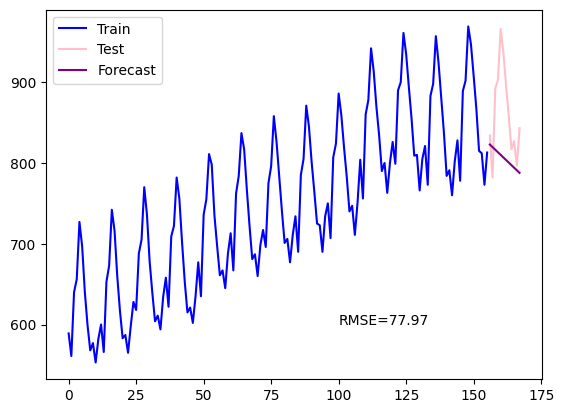

In [26]:
alpha,beta=0.3,0.1
holt=Holt(y_train)
fit1=holt.fit(smoothing_level=alpha,smoothing_trend=beta, optimized=False)
fcast1=fit1.forecast(len(y_test))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink', label='Test')
rmse=np.round(RMSE(y_test,fcast1),2)
plt.text(100,600,f'RMSE={rmse}')
fcast1.plot(color='purple',label='Forecast')
plt.legend(loc='best')
plt.show()

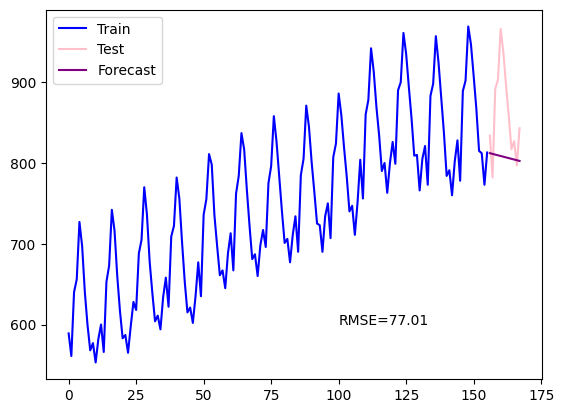

In [27]:
holt=Holt(y_train)
fit1=holt.fit()
fcast1=fit1.forecast(len(y_test))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink', label='Test')
rmse=np.round(RMSE(y_test,fcast1),2)
plt.text(100,600,f'RMSE={rmse}')
fcast1.plot(color='purple',label='Forecast')
plt.legend(loc='best')
plt.show()

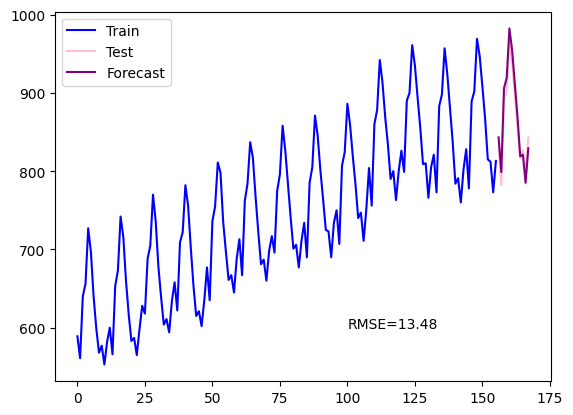

In [28]:
alpha,beta,gamma=0.3,0.1,0.4
hw=ExponentialSmoothing(y_train,seasonal_periods=12,trend='add',seasonal='add')
fit1=hw.fit(smoothing_level=alpha,smoothing_trend=beta,smoothing_seasonal=gamma, optimized=False)
fcast1=fit1.forecast(len(y_test))
y_train.plot(color='blue',label='Train')
y_test.plot(color='pink', label='Test')
rmse=np.round(RMSE(y_test,fcast1),2)
plt.text(100,600,f'RMSE={rmse}')
fcast1.plot(color='purple',label='Forecast')
plt.legend(loc='best')
plt.show()